In [1]:
!pip install kagglehub pandas gensim scikit-learn nltk matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 88.1 MB/s eta 0:00:00


In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import nltk
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [3]:
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")

files = os.listdir(path)
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)
print(df.columns)
df.head()

100%|██████████| 828k/828k [00:00<00:00, 857kB/s]

Extracting files...
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [6]:
df = df[['Ticket Description','Ticket Type']]
df.columns = ['text','label']
df = df.dropna()
df.head()

,text,label
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


In [7]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return words

df['tokens'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
sentences = df['tokens'].tolist()
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

In [9]:
def sentence_vector(tokens):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

sentence_vectors = [sentence_vector(s) for s in sentences]

In [10]:
def semantic_search(query):
    query_tokens = preprocess(query)
    query_vector = sentence_vector(query_tokens).reshape(1, -1)

    similarities = []

    for vec in sentence_vectors:
        sim = cosine_similarity(query_vector, vec.reshape(1, -1))[0][0]
        similarities.append(sim)

    best_index = np.argmax(similarities)

    print("Query:", query)
    print("Result:", df['text'].iloc[best_index])
    print("Score:", similarities[best_index])

In [11]:
semantic_search("payment failed but money deducted")
semantic_search("cannot login to my account")
semantic_search("best laptop for coding")

Query: payment failed but money deducted
Result: I'm having an issue with the {product_purchased}. Please assist.

Product Description # Product Name / Description of Products In Stock

Description of the Item # Description of the Item

Description of the Item

The I need assistance as soon as possible because it's affecting my work and productivity.
Score: 0.95609367
Query: cannot login to my account
Result: I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account?

Create a I've tried different settings and configurations on my {product_purchased}, but the issue persists.
Score: 0.89300966
Query: best laptop for coding
Result: I'm having an issue with the {product_purchased}. Please assist. Thanks!"

"As if this would help, this isn't going to go smoothly either…."

"My apologies, I apologize for getting in such I need assistance as soon as possib

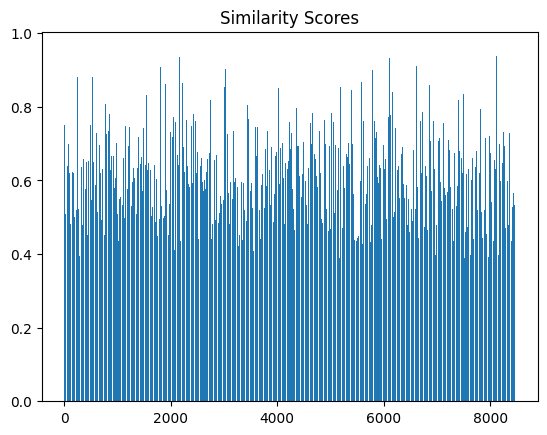

In [12]:
query = "payment failed but money deducted"
query_tokens = preprocess(query)
query_vector = sentence_vector(query_tokens).reshape(1, -1)

scores = []
for vec in sentence_vectors:
    sim = cosine_similarity(query_vector, vec.reshape(1, -1))[0][0]
    scores.append(sim)

plt.figure()
plt.bar(range(len(scores)), scores)
plt.title("Similarity Scores")
plt.show()